# 21. Cross-Sectional Portfolio Strategy

## Objective
Convert model outputs into a **portfolio-level long-short strategy** and test whether ranking-based selection extracts stronger signal than threshold-based trading.

Portfolio rule:
- Long: top 10 stocks by prediction score
- Short: bottom 10 stocks by prediction score
- Normalize weights daily
- Apply 0.1% transaction cost per trade

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 250)
pd.set_option('display.width', 220)

TOP_N = 10
TXN_COST = 0.001  # 0.1% per trade
ANNUALIZATION_DAYS = 252

logger = logging.getLogger('cross_sectional_strategy')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)

## STEP 1: Load Data

In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to resolve project root with ml_pipeline and CLAUDE.md')


def resolve_paths(root: Path) -> Dict[str, Path]:
    base = root / 'ml_pipeline'
    return {
        'strategy_results': base / 'Market_Data' / 'final' / 'final_strategy_results.parquet',
    }


ROOT = resolve_project_root()
PATHS = resolve_paths(ROOT)
assert PATHS['strategy_results'].exists(), f"Missing file: {PATHS['strategy_results']}"

df = pd.read_parquet(PATHS['strategy_results']).copy()
df['Date'] = pd.to_datetime(df['Date'])
df['Regime'] = df['Regime'].astype(str).str.upper()
df['volatility_regime_label'] = df['volatility_regime_label'].astype(str).str.upper()

# Signal preference: Transformer/ensemble if available, else Probability
signal_col = 'Probability'
for c in ['ensemble_prob', 'Ensemble_prob', 'Transformer_prob', 'transformer_prob', 'Probability']:
    if c in df.columns:
        signal_col = c
        break

required_cols = {'Ticker', 'Date', 'daily_return', 'net_return', 'volatility_regime_label', signal_col}
assert required_cols.issubset(df.columns), f"Missing required columns: {required_cols - set(df.columns)}"

logger.info('Loaded strategy rows: %s', f'{len(df):,}')
logger.info('Using signal column: %s', signal_col)
display(df[['Ticker', 'Date', signal_col, 'daily_return', 'volatility_regime_label']].head())

[INFO] Loaded strategy rows: 21,792
[INFO] Using signal column: Probability


,Ticker,Date,Probability,daily_return,volatility_regime_label
0,ABB,2025-01-29,0.494498,-0.064066,HIGH
1,ABB,2025-01-30,0.502987,0.027153,HIGH
2,ABB,2025-01-31,0.492936,-0.063859,HIGH
3,ABB,2025-02-01,0.506073,-0.054941,HIGH
4,ABB,2025-02-03,0.496291,0.083158,HIGH


## STEP 2/3: Daily Ranking and Portfolio Construction

For each date:
- rank stocks by signal
- long top 10
- short bottom 10

In [3]:
def assign_long_short_flags(day_df: pd.DataFrame, signal_column: str, top_n: int = 10) -> pd.DataFrame:
    out = day_df.copy()
    out['is_long'] = False
    out['is_short'] = False

    n = len(out)
    k = min(top_n, max(1, n // 2))

    long_idx = out[signal_column].nlargest(k).index
    short_idx = out.loc[~out.index.isin(long_idx), signal_column].nsmallest(k).index

    out.loc[long_idx, 'is_long'] = True
    out.loc[short_idx, 'is_short'] = True
    out['side'] = np.where(out['is_long'], 1, np.where(out['is_short'], -1, 0))
    out['selected'] = out['side'] != 0
    return out


ranked_df = (
    df.groupby('Date', group_keys=False)
    .apply(lambda g: assign_long_short_flags(g, signal_column=signal_col, top_n=TOP_N))
    .reset_index(drop=True)
)

logger.info('Average selected names/day: %.2f', ranked_df.groupby('Date')['selected'].sum().mean())
display(ranked_df[['Date', 'Ticker', signal_col, 'is_long', 'is_short', 'side']].head(20))

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_15016\1980260012.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: assign_long_short_flags(g, signal_column=signal_col, top_n=TOP_N))
[INFO] Average selected names/day: 20.00


,Date,Ticker,Probability,is_long,is_short,side
0,2025-01-29,ABB,0.494498,False,False,0
1,2025-01-30,ABB,0.502987,False,True,-1
2,2025-01-31,ABB,0.492936,False,False,0
3,2025-02-01,ABB,0.506073,False,False,0
4,2025-02-03,ABB,0.496291,False,False,0
5,2025-02-04,ABB,0.490754,False,False,0
6,2025-02-05,ABB,0.494325,False,False,0
7,2025-02-06,ABB,0.499879,False,True,-1
8,2025-02-07,ABB,0.497488,False,False,0
9,2025-02-10,ABB,0.502407,False,False,0


## STEP 4: Position Sizing

Implement two sizing methods:
- Equal weight
- Confidence weight based on `|signal - 0.5|`

Daily weight normalization is applied.

In [4]:
def apply_position_sizing(df_in: pd.DataFrame, signal_column: str, method: str = 'confidence') -> pd.DataFrame:
    out = df_in.copy()

    if method == 'equal':
        out['raw_abs_weight'] = np.where(out['selected'], 1.0, 0.0)
    elif method == 'confidence':
        out['raw_abs_weight'] = np.where(out['selected'], (out[signal_column] - 0.5).abs(), 0.0)
        out['raw_abs_weight'] = out['raw_abs_weight'].clip(lower=1e-8)
    else:
        raise ValueError(f'Unsupported method: {method}')

    out['daily_abs_sum'] = out.groupby('Date')['raw_abs_weight'].transform('sum')
    out['weight'] = np.where(out['daily_abs_sum'] > 0, out['raw_abs_weight'] / out['daily_abs_sum'], 0.0)
    out['weight'] = out['weight'] * out['side']
    return out


ranked_equal = apply_position_sizing(ranked_df, signal_column=signal_col, method='equal')
ranked_conf = apply_position_sizing(ranked_df, signal_column=signal_col, method='confidence')

display(ranked_conf[['Date', 'Ticker', signal_col, 'side', 'weight']].head(15))

,Date,Ticker,Probability,side,weight
0,2025-01-29,ABB,0.494498,0,0.000000
1,2025-01-30,ABB,0.502987,-1,-0.001667
2,2025-01-31,ABB,0.492936,0,0.000000
3,2025-02-01,ABB,0.506073,0,0.000000
4,2025-02-03,ABB,0.496291,0,0.000000
5,2025-02-04,ABB,0.490754,0,0.000000
6,2025-02-05,ABB,0.494325,0,0.000000
7,2025-02-06,ABB,0.499879,-1,-0.000160
8,2025-02-07,ABB,0.497488,0,0.000000
9,2025-02-10,ABB,0.502407,0,0.000000


## STEP 5/6: Portfolio Returns with Transaction Cost

In [5]:
def compute_portfolio_returns(df_sized: pd.DataFrame, txn_cost: float = 0.001) -> pd.DataFrame:
    out = df_sized.copy()
    out['gross_return'] = out['weight'] * out['daily_return']
    out['txn_cost'] = np.where(out['selected'], txn_cost * out['weight'].abs(), 0.0)
    out['net_return'] = out['gross_return'] - out['txn_cost']
    return out


cs_equal_df = compute_portfolio_returns(ranked_equal, txn_cost=TXN_COST)
cs_conf_df = compute_portfolio_returns(ranked_conf, txn_cost=TXN_COST)

display(cs_conf_df[['Date', 'Ticker', 'side', 'weight', 'daily_return', 'gross_return', 'txn_cost', 'net_return']].head(12))

,Date,Ticker,side,weight,daily_return,gross_return,txn_cost,net_return
0,2025-01-29,ABB,0,0.000000,-0.064066,-0.000000e+00,0.000000e+00,-0.000000e+00
1,2025-01-30,ABB,-1,-0.001667,0.027153,-4.527246e-05,1.667285e-06,-4.693974e-05
2,2025-01-31,ABB,0,0.000000,-0.063859,-0.000000e+00,0.000000e+00,-0.000000e+00
3,2025-02-01,ABB,0,0.000000,-0.054941,-0.000000e+00,0.000000e+00,-0.000000e+00
4,2025-02-03,ABB,0,0.000000,0.083158,0.000000e+00,0.000000e+00,0.000000e+00
5,2025-02-04,ABB,0,0.000000,0.020499,0.000000e+00,0.000000e+00,0.000000e+00
6,2025-02-05,ABB,0,0.000000,-0.011062,-0.000000e+00,0.000000e+00,-0.000000e+00
7,2025-02-06,ABB,-1,-0.000160,0.000766,-1.225144e-07,1.600087e-07,-2.825230e-07
8,2025-02-07,ABB,0,0.000000,-0.018511,-0.000000e+00,0.000000e+00,-0.000000e+00
9,2025-02-10,ABB,0,0.000000,-0.025741,-0.000000e+00,0.000000e+00,-0.000000e+00


## STEP 7: Backtest Metrics

In [6]:
def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = (equity / running_max) - 1.0
    return float(dd.min())


def sharpe_ratio(daily_returns: pd.Series, annualization: int = 252) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0:
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def summarize_strategy(position_df: pd.DataFrame, strategy_name: str) -> Dict[str, float]:
    daily = position_df.groupby('Date', as_index=True)['net_return'].sum().sort_index()
    equity = (1.0 + daily).cumprod()

    executed = position_df[position_df['selected']].copy()
    trade_returns = executed['net_return']

    return {
        'Strategy': strategy_name,
        'Total return': float(equity.iloc[-1] - 1.0),
        'Sharpe ratio': sharpe_ratio(daily, annualization=ANNUALIZATION_DAYS),
        'Max drawdown': max_drawdown(equity),
        'Win rate': float((trade_returns > 0).mean()) if len(trade_returns) > 0 else np.nan,
        'Avg return/trade': float(trade_returns.mean()) if len(trade_returns) > 0 else np.nan,
        'Coverage': float(position_df['selected'].mean()),
    }


metrics_cross_equal = summarize_strategy(cs_equal_df, 'Cross-sectional (equal weight)')
metrics_cross_conf = summarize_strategy(cs_conf_df, 'Cross-sectional (confidence weight)')
display(pd.DataFrame([metrics_cross_equal, metrics_cross_conf]).round(4))

,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate,Avg return/trade,Coverage
0,Cross-sectional (equal weight),-0.1987,-4.2978,-0.1957,0.4659,-0.0,0.2083
1,Cross-sectional (confidence weight),-0.1859,-2.1687,-0.1957,0.4659,-0.0,0.2083


## STEP 8: Benchmarks

Compare against:
- Cross-sectional strategy
- Buy & Hold
- Previous best strategy (from notebook 20 output)

In [7]:
# Buy & Hold benchmark (equal-weight long all names each day)
bh = df.copy()
bh['selected'] = True
bh['weight'] = 1.0 / bh.groupby('Date')['Ticker'].transform('count')
bh['gross_return'] = bh['weight'] * bh['daily_return']
bh['txn_cost'] = 0.0
bh['net_return'] = bh['gross_return']

# Previous best strategy benchmark from saved net_return
prev = df.copy()
prev['selected'] = prev['trade_mask'].astype(bool)
prev['weight'] = prev['weight']
prev['gross_return'] = prev['gross_return']
prev['txn_cost'] = prev['txn_cost']
prev['net_return'] = prev['net_return']

summary_df = pd.DataFrame([
    metrics_cross_conf,
    summarize_strategy(cs_equal_df, 'Cross-sectional (equal weight)'),
    summarize_strategy(bh, 'Buy & Hold'),
    summarize_strategy(prev, 'Previous best strategy'),
]).sort_values('Sharpe ratio', ascending=False).reset_index(drop=True)

display(summary_df.round(4))

,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate,Avg return/trade,Coverage
0,Previous best strategy,0.1119,2.3265,0.0000,1.0000,0.0179,0.0003
1,Buy & Hold,0.1629,1.2535,-0.0868,0.4996,0.0000,1.0000
2,Cross-sectional (confidence weight),-0.1859,-2.1687,-0.1957,0.4659,-0.0000,0.2083
3,Cross-sectional (equal weight),-0.1987,-4.2978,-0.1957,0.4659,-0.0000,0.2083


## STEP 9: Regime Analysis (Cross-sectional, confidence weight)

,Regime,Samples,Coverage,Total return,Sharpe ratio,Max drawdown,Win rate,Avg return/trade
0,HIGH,5194,0.1506,-0.0056,-0.7225,-0.0102,0.4488,-0.0000
1,LOW,11297,0.2894,-0.2040,-2.3869,-0.2170,0.4653,-0.0001
2,MEDIUM,5301,0.0922,0.0283,1.7577,-0.0038,0.4969,0.0001


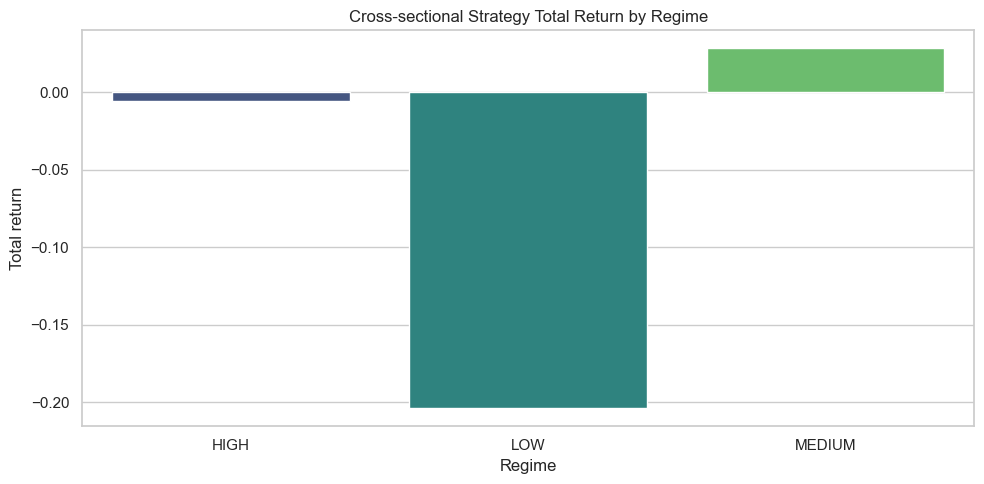

In [8]:
regime_rows = []
for regime, grp in cs_conf_df.groupby('volatility_regime_label'):
    regime_rows.append({
        'Regime': regime,
        'Samples': int(len(grp)),
        'Coverage': float(grp['selected'].mean()),
        **{k: v for k, v in summarize_strategy(grp, strategy_name=f'Regime-{regime}').items() if k != 'Strategy'}
    })

regime_perf_df = pd.DataFrame(regime_rows).sort_values('Regime').reset_index(drop=True)
display(regime_perf_df.round(4))

plt.figure(figsize=(10, 5))
sns.barplot(data=regime_perf_df, x='Regime', y='Total return', hue='Regime', palette='viridis', legend=False)
plt.title('Cross-sectional Strategy Total Return by Regime')
plt.tight_layout()
plt.show()

## Final Conclusion

In [9]:
best = summary_df.iloc[0]
print('Cross-sectional backtest completed.')
print(f"Best strategy by Sharpe: {best['Strategy']}")
print(f"Sharpe: {best['Sharpe ratio']:.4f} | Total return: {best['Total return']:.4f} | Max drawdown: {best['Max drawdown']:.4f}")
print('Goal check: ranking-based signal extraction benchmarked against threshold-based system.')

Cross-sectional backtest completed.
Best strategy by Sharpe: Previous best strategy
Sharpe: 2.3265 | Total return: 0.1119 | Max drawdown: 0.0000
Goal check: ranking-based signal extraction benchmarked against threshold-based system.
